<!-- # P-CULTA Baseline Evaluation — v2
## Zero-Shot | 4 Models | CAS · FTV (independent) · Bias



<!-- # P-CULTA Baseline Evaluation — v2
## Zero-Shot | 4 Models | CAS · FTV (independent) · Bias

**Fixes applied in this version:**
- Prompt now includes User Role + Model Role (so models know their social position)
- FTV is independently human-judged — 2 dedicated FTV dimensions added to annotation sheet
- CAS uses weighted dimensions (Indirectness + Facesaving weighted higher — culturally justified)
- Preference validation cell added for CAS metric validation
- Gold responses annotated by judges — not hardcoded

**Models:**
| Model | Type |
|-------|------|
| GPT-4o-mini | Closed LLM — commercial baseline |
| Qwen2.5-7B-Instruct | Open LLM — multilingual baseline |
| LLaMA-3.1-8B-Instruct | Open LLM — instruction-following baseline |
| Qalb-1.0-8B-Instruct | Urdu-native LLM — regional baseline | -->

## 0. Install & Import

In [ ]:
import sys

!{sys.executable} -m pip install -U \
transformers \
accelerate \
bitsandbytes \
sentencepiece \
huggingface_hub

In [2]:
# !pip install openai transformers accelerate bitsandbytes pandas scipy scikit-learn matplotlib seaborn tqdm -q
# !pip install -q openai
import os, time, warnings, json
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm.notebook import tqdm
from scipy import stats
from sklearn.metrics import cohen_kappa_score
from collections import Counter

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'
})

COLORS = {
    'GPT-4o-mini':                '#2166AC',
    'Qwen2.5-7B-Instruct':        '#1B7837',
    'Meta-Llama-3.1-8B-Instruct': '#D6604D',
    'Qalb-1.0-8B-Instruct':       '#7B2D8B',
}

print("✓ Ready")

✓ Ready


## 1. Load Dataset

In [2]:
df = pd.read_csv(r"P_CULTA_V2.csv")

for col in ['Topic','Power Distance','Register','Sensitivity',
            'User Role','Model Role']:
    df[col] = df[col].str.strip()
df['Sensitivity'] = df['Sensitivity'].str.capitalize()
df = df.reset_index(drop=True)
df.insert(0, 'ID', range(1, len(df)+1))

print(f"Rows: {len(df)}  |  Topics: {df['Topic'].nunique()}")
print(f"Power Distance: {dict(Counter(df['Power Distance']))}")
print(f"Sensitivity:    {dict(Counter(df['Sensitivity']))}")
print(f"Register:       {dict(Counter(df['Register']))}")
df.head(3)

Rows: 255  |  Topics: 17
Power Distance: {'Medium': 70, 'Low': 73, 'High': 112}
Sensitivity:    {'Positive': 96, 'Negative': 74, 'Neutral': 85}
Register:       {'Formal': 164, 'Informal': 91}


,ID,Language,Topic,User Role,Model Role,Power Distance,Register,Pragmatic Genre,Sensitivity,User Utterance,Context,Gold Response
0,1,Urdu,Refusing Offers,میزبان,مہمان,Medium,Formal,Gratitude + indirect refusal,Positive,اور سالن لے لیجیے، ابھی گرم ہے۔,آپ ایک دعوت میں مہمان ہیں۔ کھانے کے دوران میزب...,آپ کی بڑی مہربانی، واقعی بہت مزیدار تھا، مگر ا...
1,2,Urdu,Refusing Offers,دوست,دوست,Low,Informal,Polite refusal,Negative,اور چائے بنوا دوں؟,آپ اپنے دوست کے گھر ملاقات کے لیے گئے ہیں۔ گفت...,نہیں یار، تم نے پہلے ہی بہت خاطر داری کر لی ہے...
2,3,Urdu,Refusing Offers,ساس,بہو,High,Formal,Deferential refusal,Positive,بیٹا، اور روٹی لے لو۔,آپ گھر میں کھانے کی میز پر موجود ہیں۔ کھانے کے...,جی امی جان، بہت شکریہ، مگر واقعی اب مزید گنجائ...


## 2. Prompt Builder

**What goes in the prompt:**
- `User Utterance` — what was said

**What does NOT go in the prompt :**
- No topics
- No context
- No roles
- No cultural instruction
- No Pakistan mention
- No examples
- No chain-of-thought
- No power distance label
- No sensitivity label


In [3]:
def build_baseline_prompt(row: pd.Series) -> tuple[str, str]:
    """
    system : role-play instruction only — no culture, no Pakistan,
             no roles, no context, no topic, no examples
    user   : only the user utterance

    Gold response is NEVER shown — judges score independently.
    """
    system = (
        "Generate a natural Urdu response. "
        "Output only the response utterance. "
        "Do not explain. "
        "Do not narrate. "
        "Do not add extra context. "
        "Do not ask unnecessary follow-up questions."
    )

    user = (
        f"\"{row['User Utterance']}\""
    )

    return system, user



for i in [0, 80, 130]:
    r = df.iloc[i]
    sys_msg, usr_msg = build_baseline_prompt(r)

    print(f"Row {i}")
    print(f"SYSTEM: {sys_msg}")
    print(f"USER:\n{usr_msg}")
    print("─" * 60)

Row 0
SYSTEM: Generate a natural Urdu response. Output only the response utterance. Do not explain. Do not narrate. Do not add extra context. Do not ask unnecessary follow-up questions.
USER:
"اور سالن لے لیجیے، ابھی گرم ہے۔"
────────────────────────────────────────────────────────────
Row 80
SYSTEM: Generate a natural Urdu response. Output only the response utterance. Do not explain. Do not narrate. Do not add extra context. Do not ask unnecessary follow-up questions.
USER:
"میں بل دے دیتی ہوں۔"
────────────────────────────────────────────────────────────
Row 130
SYSTEM: Generate a natural Urdu response. Output only the response utterance. Do not explain. Do not narrate. Do not add extra context. Do not ask unnecessary follow-up questions.
USER:
"میں نے منع کیا تھا، پھر بھی تم نے یہ کام کیا۔"
────────────────────────────────────────────────────────────


## 3. Response Generation

### 3.1 GPT-4o-mini

In [ ]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
from openai import OpenAI, RateLimitError

def generate_gpt(df: pd.DataFrame, api_key: str,
                 save_path: str = "responses_gpt_utterance.csv") -> pd.DataFrame:

    client    = OpenAI(api_key=api_key)
    responses = []

    for i, row in tqdm(df.iterrows(), total=len(df), desc="GPT-4o-mini"):
        system, user = build_baseline_prompt(row)
        retries, text = 0, "ERROR"

        while retries < 5:
            try:
                resp = client.chat.completions.create(
                    model="gpt-4o-mini",
                    temperature=0.3,
                    max_tokens=40,
                    messages=[
                        {"role": "system", "content": system},
                        {"role": "user",   "content": user},
                    ]
                )
                text = resp.choices[0].message.content.strip()
                break
            except RateLimitError:
                wait = 2 ** retries
                print(f"  Rate limit — waiting {wait}s")
                time.sleep(wait)
                retries += 1
            except Exception as e:
                print(f"  Error row {i}: {e}")
                break

        responses.append(text)

        if i % 25 == 0 and i > 0:
            tmp = df.copy()
            tmp['GPT_Response'] = responses + [''] * (len(df) - len(responses))
            tmp.to_csv(save_path.replace('.csv','_backup.csv'),
                       index=False, encoding='utf-8-sig')
        time.sleep(1.2)

    out = df.copy()
    out['GPT_Response'] = responses
    out.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f"Saved → {save_path}")
    return out
df_gpt = generate_gpt(df, OPENAI_API_KEY)
# df_gpt = pd.read_csv('responses_gpt_utterance.csv')

### 3.2 HuggingFace Models (Qwen · LLaMA · Qalb)

In [ ]:
def generate_hf(df: pd.DataFrame, model_id: str,
                save_path: str, response_col: str) -> pd.DataFrame:
    """
    Works for: Qwen2.5-7B-Instruct, LLaMA-3.1-8B-Instruct, Qalb-1.0-8B-Instruct
    Needs: GPU ≥ 16GB VRAM  (or Google Colab A100)
    """
    import torch
    from transformers import (AutoTokenizer, AutoModelForCausalLM,
                               BitsAndBytesConfig)

    model_name = model_id.split('/')[-1]
    print(f"Loading {model_name}...")

    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_id, quantization_config=bnb,
        device_map="auto", trust_remote_code=True)
    tokenizer = AutoTokenizer.from_pretrained(
        model_id, trust_remote_code=True)

    responses = []

    for i, row in tqdm(df.iterrows(), total=len(df), desc=model_name):
        system, user = build_baseline_prompt(row)
        messages = [{"role":"system","content":system},
                    {"role":"user",  "content":user}]

        try:
            text_in = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True)
        except Exception:
            text_in = f"{system}\n{user}\n"

        inputs = tokenizer(text_in, return_tensors="pt").to(model.device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=40, temperature=0.3,
                do_sample=True, pad_token_id=tokenizer.eos_token_id,
                repetition_penalty=1.1)

        new_tok  = out[0][inputs['input_ids'].shape[1]:]
        response = tokenizer.decode(new_tok, skip_special_tokens=True).strip()
        responses.append(response)

        if i % 25 == 0 and i > 0:
            tmp = df.copy()
            tmp[response_col] = responses + [''] * (len(df)-len(responses))
            tmp.to_csv(save_path.replace('.csv','_backup.csv'),
                       index=False, encoding='utf-8-sig')

    out = df.copy()
    out[response_col] = responses
    out.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f"Saved → {save_path}")
    return out

# df_qwen  = generate_hf(df, "Qwen/Qwen2.5-7B-Instruct",
#                         "responses_qwen_utterance.csv",  "Qwen_Response")
df_llama = generate_hf(df, "meta-llama/Meta-Llama-3.1-8B-Instruct",
                         "responses_llama_utterance.csv", "LLaMA_Response")
df_qalb  = generate_hf(df, "enstazao/Qalb-1.0-8B-Instruct",
                         "responses_qalb_utterance.csv",  "Qalb_Response")

### 3.3 Merge All Responses

In [4]:
df_gpt   = pd.read_csv(r'responses_gpt_utterance.csv')
df_qwen  = pd.read_csv(r'responses_qwen_utterance.csv')
df_llama = pd.read_csv(r'responses_llama_utterance.csv')
df_qalb  = pd.read_csv(r'responses_qalb_utterance.csv')

merged = df_gpt.copy()
for other, col in [(df_qwen,  'Qwen_Response'),
                   (df_llama, 'LLaMA_Response'),
                   (df_qalb,  'Qalb_Response')]:
    merged = merged.merge(other[['ID', col]], on='ID', how='left')

RESPONSE_COLS = {
    'GPT-4o-mini':                'GPT_Response',
    'Qwen2.5-7B-Instruct':        'Qwen_Response',
    'Meta-Llama-3.1-8B-Instruct': 'LLaMA_Response',
    'Qalb-1.0-8B-Instruct':       'Qalb_Response',
}

print(f"Merged: {len(merged)} rows")
for model, col in RESPONSE_COLS.items():
    n = merged[col].notna().sum()
    print(f"  {model:38s} {n} responses")

merged.head(3)

Merged: 255 rows
  GPT-4o-mini                            255 responses
  Qwen2.5-7B-Instruct                    255 responses
  Meta-Llama-3.1-8B-Instruct             255 responses
  Qalb-1.0-8B-Instruct                   255 responses


,ID,Language,Topic,User Role,Model Role,Power Distance,Register,Pragmatic Genre,Sensitivity,User Utterance,Context,Gold Response,GPT_Response,Qwen_Response,LLaMA_Response,Qalb_Response
0,1,Urdu,Refusing Offers,میزبان,مہمان,Medium,Formal,Gratitude + indirect refusal,Positive,اور سالن لے لیجیے، ابھی گرم ہے۔,آپ ایک دعوت میں مہمان ہیں۔ کھانے کے دوران میزب...,آپ کی بڑی مہربانی، واقعی بہت مزیدار تھا، مگر ا...,"""شکریہ، بہت مہربانی۔""",اس وقت کافی دماغت سے پلے جا رہے ہیں۔,"""کیا کروں؟ وہ تو پانی میں ڈوب جائیں گے۔""","Now that you have taken the salt, it is still ..."
1,2,Urdu,Refusing Offers,دوست,دوست,Low,Informal,Polite refusal,Negative,اور چائے بنوا دوں؟,آپ اپنے دوست کے گھر ملاقات کے لیے گئے ہیں۔ گفت...,نہیں یار، تم نے پہلے ہی بہت خاطر داری کر لی ہے...,"""جی، ضرور، چائے بنا دیں۔""",آپ کیا میں نے آپ کی تعاون سے چایہ بنانے کے لئے...,"""جی، بہت اچھا، میں چائے بناؤں!""",I will make tea.
2,3,Urdu,Refusing Offers,ساس,بہو,High,Formal,Deferential refusal,Positive,بیٹا، اور روٹی لے لو۔,آپ گھر میں کھانے کی میز پر موجود ہیں۔ کھانے کے...,جی امی جان، بہت شکریہ، مگر واقعی اب مزید گنجائ...,"""جی، اب لے لیتا ہوں۔""",اب تیر کی روٹی لے کر آئے گے۔,"""ابھی کبھی نہیں، والدہ جی، مجھے پانی پی کر آوں...","Son, bring some bread too."


## 4. Annotation Sheets

**6 columns to fill per response (0–4 scale):**

**CAS dimensions** (higher = better cultural alignment):
- `Relational_Alignment` — appropriateness of the interpersonal relationship, including suitable respect, familiarity, warmth, acknowledgment, and deference for the specified roles and power distance.
- `Indirectness` — polite indirect phrasing used
- `Facesaving` — interlocutor's izzat protected
- `Cultural_Appropriateness` — overall fit to Pakistani norms

**FTV dimensions — independently judged** (higher = more face-threatening):
- `Directness_Threat` — how bluntly does response impose or refuse?
- `Hierarchy_Violation` — wrong register for the role relationship?

**Scale:**
| Score | Meaning |
|-------|---------|
| 0 | Absent / completely wrong |
| 1 | Weak presence/ major shortcomings |
| 2 | Partial / acceptable |
| 3 | Strong realization/ minor shortcomings |
| 4 | Full / culturally appropriate |

**Also annotate Gold Responses** using same 6 dimensions.
These become the true gold scores — not hardcoded values.

In [5]:
def create_annotation_sheets(merged: pd.DataFrame,
                              response_cols: dict,
                              n_judges: int = 3,
                              out_dir: str = "annotation_utterance"):

    Path(out_dir).mkdir(exist_ok=True)
    rng    = np.random.default_rng(42)
    models = list(response_cols.keys())
    labels = list('ABCD')[:len(models)]

    
    CAS_DIMS = ['Relational_Alignment','Indirectness','Facesaving',
                'Cultural_Appropriateness']
    FTV_DIMS = ['Directness_Threat','Hierarchy_Violation']
    ALL_DIMS = CAS_DIMS + FTV_DIMS

    all_mappings = []

    for judge_idx in range(1, n_judges + 1):
        rows = []
        mappings = []

        for _, row in merged.iterrows():
            order = rng.permutation(models).tolist()

            sheet_row = {
                'ID':             row['ID'],
                'User_Utterance': row['User Utterance'],
                'Gold_Response':  row['Gold Response'],
            }

            
            for dim in ALL_DIMS:
                sheet_row[f'Gold_{dim}'] = ''

           
            for label, model in zip(labels, order):
                col = response_cols[model]
                sheet_row[f'Response_{label}'] = row.get(col, '')
                for dim in ALL_DIMS:
                    sheet_row[f'{label}_{dim}'] = ''

            rows.append(sheet_row)

            m = {'ID': row['ID'], 'Judge': f'Judge{judge_idx}'}
            for label, model in zip(labels, order):
                m[label] = model
            mappings.append(m)

        sheet_path = f"{out_dir}/judge{judge_idx}_utterance_only.csv"
        pd.DataFrame(rows).to_csv(
            sheet_path,
            index=False,
            encoding='utf-8-sig'
        )
        print(f"  Saved: {sheet_path}")
        all_mappings.extend(mappings)

    mapping_path = f"{out_dir}/mapping_key_utterance_only.csv"
    pd.DataFrame(all_mappings).to_csv(mapping_path, index=False)
    print(f"  Saved: {mapping_path}  ← DO NOT share with judges")
    print(
        f"\nEach judge scores {len(merged)} rows × "
        f"{len(models)} responses × {len(ALL_DIMS)} dims"
    )
    print(f"  CAS dims: {CAS_DIMS}")
    print(f"  FTV dims (independent): {FTV_DIMS}")


create_annotation_sheets(merged, RESPONSE_COLS)

  Saved: annotation_utterance/judge1_utterance_only.csv
  Saved: annotation_utterance/judge2_utterance_only.csv
  Saved: annotation_utterance/mapping_key_utterance_only.csv  ← DO NOT share with judges

Each judge scores 255 rows × 4 responses × 6 dims
  CAS dims: ['Relational_Alignment', 'Indirectness', 'Facesaving', 'Cultural_Appropriateness']
  FTV dims (independent): ['Directness_Threat', 'Hierarchy_Violation']


## 5. Metric Computation

### Formulas

**CAS** — average of 4 CAS dimensions, compared to gold:
```
  CAS  = 1 - mean( |model_i - gold_i| / S_MAX )   equal weights
    

```

**FTV** — independently human-judged,  average of 2 FTV dimensions:
```
FTV  = mean( model_j / S_MAX )                   equal weights

FTV is now a genuinely independent metric — judges score it separately
from CAS dimensions. It no longer derives from the Indirectness score.
```

**Bias**:
```
Bias = 1 - CAS
```

In [6]:


CAS_DIMS = [
    'Relational_Alignment',
    'Indirectness',
    'Facesaving',
    'Cultural_Appropriateness',
]

FTV_DIMS = [
    'Directness_Threat',
    'Hierarchy_Violation',
]

ALL_DIMS = CAS_DIMS + FTV_DIMS
S_MAX    = 4.0     # 0–4 scale
LABELS   = ['A', 'B', 'C', 'D']


def load_sheet(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    for c in df.columns:
        if any(dim in c for dim in ALL_DIMS):
            df[c] = pd.to_numeric(df[c], errors='coerce')

    return df


def load_mapping(path: str) -> pd.DataFrame:
    """Load mapping key — supports .csv or .xls/.xlsx."""
    if path.endswith('.xls') or path.endswith('.xlsx'):
        try:
            return pd.read_excel(path, engine='openpyxl')
        except Exception:
            return pd.read_csv(path, encoding='utf-8-sig')

    return pd.read_csv(path)


def compute_all_metrics(
    judges: list[pd.DataFrame],
    mapping: pd.DataFrame
) -> pd.DataFrame:
    """
    Average three judges → compute CAS, FTV, Bias per (item, model).

    CAS  = 1 - mean(|model_i - gold_i| / S_MAX)
           over the 4 CAS dimensions, equal weights.

    FTV  = mean(model_j / S_MAX)
           over the 2 FTV dimensions, equal weights.

    Bias = 1 - CAS

    Judges:
        Judge1
        Judge2
        Judge3
    """

    if len(judges) != 3:
        raise ValueError(
            f"Expected exactly 3 judges, but received {len(judges)}."
        )

    j1, j2, j3 = judges

    # ── Average the three judges for all score columns ───────────────────
    averaged = j1.copy()

    for label in LABELS + ['Gold']:
        for dim in ALL_DIMS:

            col = f'{label}_{dim}'

            if (
                col in j1.columns
                and col in j2.columns
                and col in j3.columns
            ):
                averaged[col] = (
                    j1[col]
                    + j2[col]
                    + j3[col]
                ) / 3.0

    
    map_j1 = mapping[mapping['Judge'] == 'Judge1']

    rows = []

    for _, arow in averaged.iterrows():

        item_id = arow['ID']

        mrow = map_j1[map_j1['ID'] == item_id]

        if len(mrow) == 0:
            continue

        mrow = mrow.iloc[0]

        
        gold = {
            dim: arow.get(f'Gold_{dim}', np.nan)
            for dim in ALL_DIMS
        }

        
        for label in LABELS:

            model = mrow.get(
                label,
                f'Unknown_{label}'
            )

            ms = {
                dim: arow.get(f'{label}_{dim}', np.nan)
                for dim in ALL_DIMS
            }

            
            diffs = [
                abs(ms[d] - gold[d]) / S_MAX
                for d in CAS_DIMS
                if pd.notna(ms[d])
                and pd.notna(gold[d])
            ]

            cas = (
                1.0 - np.mean(diffs)
                if diffs
                else np.nan
            )

            
            ftv_vals = [
                ms[d] / S_MAX
                for d in FTV_DIMS
                if pd.notna(ms[d])
            ]

            ftv = (
                np.mean(ftv_vals)
                if ftv_vals
                else np.nan
            )

            
            bias = (
                1.0 - cas
                if pd.notna(cas)
                else np.nan
            )

            rows.append({
                'ID':             item_id,
                'Model':          model,
                'Topic':          arow.get('Topic', ''),
                'Power_Distance': arow.get('Power_Distance', ''),
                'Register':       arow.get('Register', ''),
                'Sensitivity':    arow.get('Sensitivity', ''),

                'CAS': round(
                    float(cas), 4
                ) if pd.notna(cas) else np.nan,

                'FTV': round(
                    float(ftv), 4
                ) if pd.notna(ftv) else np.nan,

                'Bias': round(
                    float(bias), 4
                ) if pd.notna(bias) else np.nan,

                **{
                    f'model_{d}': ms[d]
                    for d in ALL_DIMS
                },

                **{
                    f'gold_{d}': gold[d]
                    for d in ALL_DIMS
                },
            })

    return pd.DataFrame(rows)




j1 = load_sheet(
    r'annotation_utterance/judge1_utterance_only_annotated.csv'
)

j2 = load_sheet(
    r'annotation_utterance/judge2_utterance_only_annotated.csv'
)

j3 = load_sheet(
    r'annotation_utterance/judge3_utterance_only_annotated.csv'
)

mapping = load_mapping(
    r'annotation_utterance/mapping_key_utterance_only.csv'
)




results = compute_all_metrics(
    [j1, j2, j3],
    mapping
)



results.to_csv(
    'baseline_utterance_results.csv',
    index=False,
    encoding='utf-8-sig'
)




print(
    f"Results: {len(results)} rows "
    f"({results['Model'].nunique()} models × "
    f"{results['ID'].nunique()} items)"
)

print()

print(
    results
    .groupby('Model')[['CAS', 'FTV', 'Bias']]
    .mean()
    .round(4)
    .to_string()
)

Results: 1020 rows (4 models × 255 items)

                               CAS     FTV    Bias
Model                                             
GPT-4o-mini                 0.5502  0.1865  0.4498
Meta-Llama-3.1-8B-Instruct  0.2256  0.3816  0.7744
Qalb-1.0-8B-Instruct        0.0335  0.4520  0.9665
Qwen2.5-7B-Instruct         0.1044  0.4694  0.8956


## 6. Inter-Annotator Agreement (Cohen's κ)

In [7]:
def compute_kappas(j1: pd.DataFrame, j2: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for dim in ALL_DIMS:
        r1_all, r2_all = [], []
        for label in LABELS + ['Gold']:
            col = f'{label}_{dim}'
            if col in j1.columns and col in j2.columns:
                mask = j1[col].notna() & j2[col].notna()
                r1_all.extend(j1.loc[mask, col].astype(int).tolist())
                r2_all.extend(j2.loc[mask, col].astype(int).tolist())

        if len(r1_all) < 5:
            continue

        kappa    = cohen_kappa_score(r1_all, r2_all, weights='quadratic')
        strength = ('Almost Perfect' if kappa > 0.80 else
                    'Substantial'    if kappa > 0.61 else
                    'Moderate'       if kappa > 0.41 else 'Fair')
        metric   = 'CAS' if dim in CAS_DIMS else 'FTV'

        rows.append({
            'Dimension': dim, 'Metric': metric,
            'κ': round(kappa, 4), 'Strength': strength, 'N': len(r1_all)
        })

    return pd.DataFrame(rows)


kappas = compute_kappas(j1, j2)
print("=== Inter-Annotator Agreement (quadratic weighted κ) ===")
print(kappas.to_string(index=False))

min_k = kappas['κ'].min()
print()
if min_k < 0.61:
    print(f"⚠  Minimum κ = {min_k:.4f} — calibration session recommended")
else:
    print(f"✓  All κ ≥ 0.61 — acceptable for publication")

kappas.to_csv('baseline_kappas_utterance.csv', index=False)


=== Inter-Annotator Agreement (quadratic weighted κ) ===
               Dimension Metric      κ       Strength    N
    Relational_Alignment    CAS 0.9917 Almost Perfect 1275
            Indirectness    CAS 0.9907 Almost Perfect 1275
              Facesaving    CAS 0.9964 Almost Perfect 1275
Cultural_Appropriateness    CAS 0.9982 Almost Perfect 1275
       Directness_Threat    FTV 0.9951 Almost Perfect 1275
     Hierarchy_Violation    FTV 0.9873 Almost Perfect 1275

✓  All κ ≥ 0.61 — acceptable for publication


## 7. Summary Statistics

In [8]:
summary = (
    results.groupby('Model')[['CAS','FTV','Bias']]
    .agg(
        CAS_mean  =('CAS', 'mean'),  CAS_std  =('CAS', 'std'),
        FTV_mean  =('FTV', 'mean'),  FTV_std  =('FTV', 'std'),
        Bias_mean =('Bias','mean'),  Bias_std =('Bias','std'),
    )
    .round(4).reset_index()
)

summary['CAS']  = summary.apply(lambda r: f"{r.CAS_mean:.3f} ± {r.CAS_std:.3f}",  axis=1)
summary['FTV']  = summary.apply(lambda r: f"{r.FTV_mean:.3f} ± {r.FTV_std:.3f}",  axis=1)
summary['Bias'] = summary.apply(lambda r: f"{r.Bias_mean:.3f} ± {r.Bias_std:.3f}",axis=1)

print("=== UTTERANCE BASELINE RESULTS TABLE ===")
print(summary[['Model','CAS','FTV','Bias']].to_string(index=False))
summary.to_csv('baseline_utterance_summary.csv', index=False)

=== UTTERANCE BASELINE RESULTS TABLE ===
                     Model           CAS           FTV          Bias
               GPT-4o-mini 0.550 ± 0.300 0.186 ± 0.201 0.450 ± 0.300
Meta-Llama-3.1-8B-Instruct 0.226 ± 0.219 0.382 ± 0.231 0.774 ± 0.219
      Qalb-1.0-8B-Instruct 0.034 ± 0.077 0.452 ± 0.188 0.967 ± 0.077
       Qwen2.5-7B-Instruct 0.104 ± 0.137 0.469 ± 0.223 0.896 ± 0.137


## 9. Figures

### Fig 1 — CAS · FTV comparison

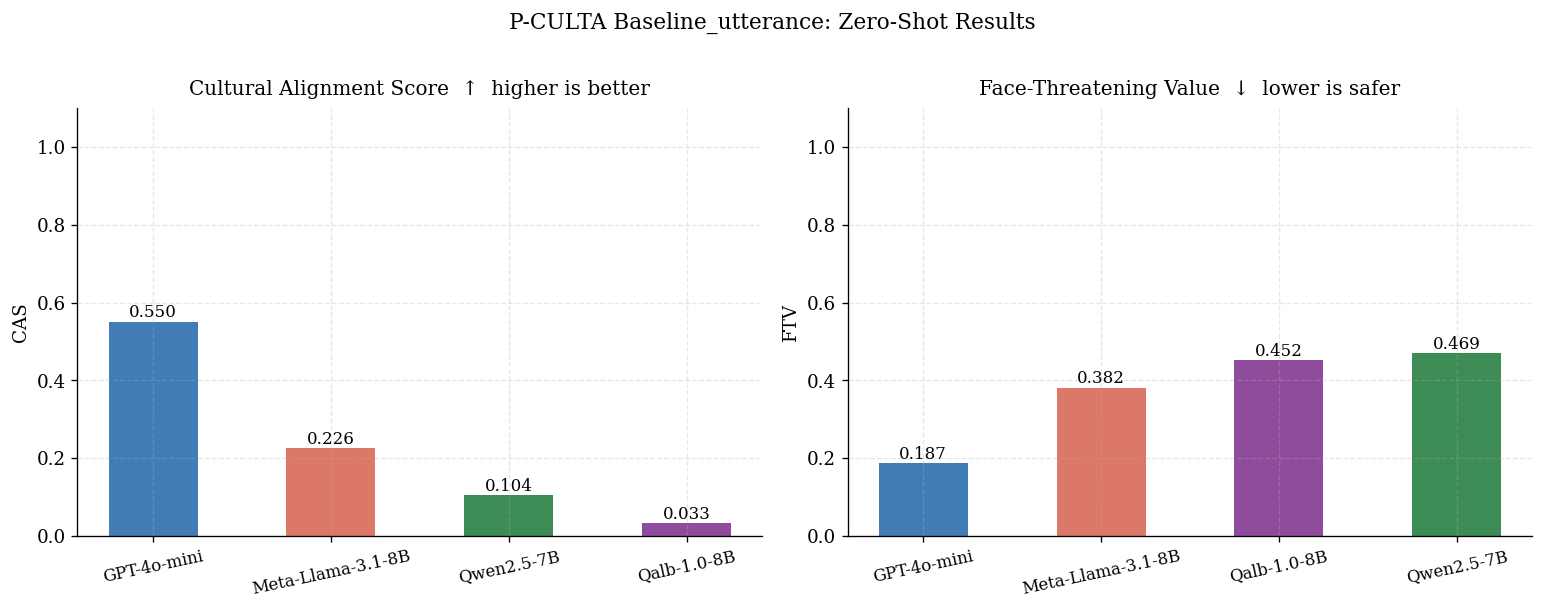

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(
    axes,
    ['CAS', 'FTV'],
    ['Cultural Alignment Score  ↑  higher is better',
     'Face-Threatening Value  ↓  lower is safer']
):
    means = (results.groupby('Model')[metric].mean()
             .sort_values(ascending=(metric=='FTV')))
    colors = [COLORS.get(m,'#888') for m in means.index]

    bars = ax.bar(range(len(means)), means.values,
                  color=colors, alpha=0.85, width=0.5)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.012,
                f'{val:.3f}', ha='center', fontsize=10)

    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(
        [m.replace('-Instruct','') for m in means.index],
        rotation=12, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(title, fontsize=12, pad=8)

plt.suptitle('P-CULTA Baseline_utterance: Zero-Shot Results', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig1_cas_ftv_utterance.pdf')
plt.savefig('fig1_cas_ftv_utterance.png', dpi=300)
plt.show()

### Fig 2 — Bias evidence

In [11]:
bias_evidence = []

for model in results['Model'].unique():
    top = results[results['Model']==model].nlargest(3,'FTV')
    for _, r in top.iterrows():
        item = merged[merged['ID'] == r['ID']].iloc[0]
        col  = RESPONSE_COLS.get(model, '')
        resp = item.get(col,'') if col else ''
        bias_evidence.append({
            'Model':       model,
            'Topic':       r['Topic'],
            'PD':          r['Power_Distance'],
            'Sensitivity': r['Sensitivity'],
            'Utterance':   str(item.get('User Utterance','')),
            'Gold':        str(item.get('Gold Response','')),
            'Response':    str(resp)[:100],
            'CAS':         r['CAS'],
            'FTV':         r['FTV'],
            'Bias':        r['Bias'],
        })

bias_df = (pd.DataFrame(bias_evidence)
           .sort_values('FTV', ascending=False))
bias_df.to_csv('baseline_utterance_bias_evidence.csv',
               index=False, encoding='utf-8-sig')

print("=== TOP FACE-THREATENING RESPONSES (Bias Evidence) ===")
for _, row in bias_df.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"[{row['Topic']} | {row['PD']} PD | {row['Sensitivity']}]")
    print(f"Utterance: {row['Utterance']}")
    print(f"Gold:      {row['Gold']}")
    print(f"Response:  {row['Response']}")
    print(f"CAS={row['CAS']:.3f}  FTV={row['FTV']:.3f}  Bias={row['Bias']:.3f}")

=== TOP FACE-THREATENING RESPONSES (Bias Evidence) ===

Model: Meta-Llama-3.1-8B-Instruct
[ |  PD | ]
Utterance: میں نے تم سے منع کیا تھا، پھر یہ کیوں کیا؟
Gold:      جی ابو، مجھ سے غلط فیصلہ ہو گیا، آئندہ آپ کی بات کا زیادہ خیال رکھوں گا۔
Response:  "کیا تو مجھے بتائیے کہ میں نے کیا کیا کیا کیا کیا کیا کیا کیا کیا ک
CAS=0.000  FTV=0.875  Bias=1.000

Model: Qalb-1.0-8B-Instruct
[ |  PD | ]
Utterance: کیا میں اس حصے کی مزید وضاحت کر دوں؟
Gold:      سر، آپ کی مہربانی، میں ایک بار خود بھی دیکھ لیتا ہوں، پھر ضرورت ہوئی تو آپ سے پوچھ لوں گا۔
Response:  Yes, I can generate more details about this part.
CAS=0.000  FTV=0.750  Bias=1.000

Model: Qalb-1.0-8B-Instruct
[ |  PD | ]
Utterance: ذرا میرا بیگ پکڑ لو، ہاتھ بھرے ہوئے ہیں۔
Gold:      ہاں، دو، میں سنبھال لیتی ہوں۔
Response:  "بیگ کیسے پکڑو؟"
"آپ کوئی ایسی چیز دیکھ رہے ہیں جو آپ کی
CAS=0.031  FTV=0.750  Bias=0.969

Model: Qalb-1.0-8B-Instruct
[ |  PD | ]
Utterance: آج مہمان آ رہے ہیں، کھانے کا انتظام کرنا ہے۔
Gold:      جی امی جان، آپ بتا د